# Synthetic Dataset Generator for Solar-Powered IoT Nodes

This notebook generates a synthetic dataset to evaluate design configurations of solar-powered IoT nodes.  
Simplified model includes: 

- Real hourly irradiance and temperature data (8760 hours).
- Photovoltaic panels of multiple realistic sizes (1–400 cm²).
- Battery capacities expressed in mAh, typical for IoT devices.
- Temperature losses in the PV module, PMU conversion losses, battery charge/discharge efficiency, and minimum allowed SOC.
- Hour-by-hour simulation of the battery State of Charge (SoC) for an entire year.
- Aggregated viability metrics per configuration.

The goal is to identify panel–battery combinations that provide sufficient energy autonomy under realistic environmental conditions.


## Workflow

### **C1 setup_constants**
Defines:
- Node power consumption.
- PV panel performance parameters (η_STC, γ, NOCT).
- PMU efficiency.
- Battery constants (nominal voltage, charge/discharge efficiency, SOC minimum).
- Realistic list of PV panel areas (1–400 cm²).
- Realistic list of battery capacities in mAh.

### **C2 build_design_space**
Creates all possible combinations:

(panel_area_m2 × battery_capacity_mAh × eta_PMU)

Each combination represents one independent system configuration.

### **C3 load_irradiance_data**
Loads the file `irradiance.csv` containing:

Month, Day, Hour, G_h, T_amb

The simulation does not use actual dates or years; it assumes a continuous sequence of hours.

### **C4 compute_pv_power**
For each panel size and hour, computes:
- PV module temperature using the NOCT model.
- Temperature-corrected PV efficiency.
- PV electrical power output (`P_PV`).

Produces a long-format dataset (`df_pv`) with one row per:

hour × panel_area_m2

### **C5 compute_hourly_balance**
Computes:
- PMU-adjusted power (`P_PMU`).
- Net power balance:

P_BAT = P_PMU − NODE_POWER_W

- Net charging/discharging current using the battery voltage:

I_BAT_mA = (P_BAT / BATTERY_VOLTAGE) × 1000

### **C6 simulate_battery_soc**
Simulates the battery SoC hour by hour for every configuration:
- Iterates over all (panel × battery) combinations.
- Integrates the net current in mAh.
- Applies charge/discharge efficiency.
- Enforces SOC bounds: `SOC_MIN ≤ SoC ≤ 1`.

The resulting dataset `df_soc` contains:

hour_index, panel_area_m2, battery_capacity_mAh, SoC, I_BAT_mA, ...

### **C7 evaluate_viability**
Computes aggregated performance metrics per configuration, including:
- Fraction of time at SOC minimum (`soc_min_fraction`)
- Fraction of time at full SOC (`soc_full_fraction`)
- Surplus and deficit current-hours (`surplus_mAh`, `deficit_mAh`)
- Net energy balance (`net_mAh`)
- **Longest continuous autonomy** before reaching SOC_MIN (`autonomy_hours`)
- Mean and standard deviation of SoC over the year (`soc_mean`, `soc_std`)

The result is the table `summary`, used for interpretation and visual analysis.

## Input Files

- **irradiance.csv**  
  Hourly irradiance (Gh) and temperature (Tamb) data used for simulation.

## Final Notes

This pipeline is designed to:
- Explore a wide configuration space efficiently.
- Support future extensions (panel tilt, variable loads, PMU models, etc.).
- Remain scalable thanks to long-format data representation.



In [1]:
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
import plotly
import numpy as np
import plotly.express as px

## Column definitions 

### Dataset `df_pv`
| Column name       | Unit | Description |
|-------------------|------|-------------|
| `hour_index`      | —    | Sequential hour index starting at 0 (0–8759) |
| `Month`           | —    | Calendar month from input dataset |
| `Day`             | —    | Calendar day from input dataset |
| `Hour`            | —    | Hour of day (0–23) from input dataset |
| `panel_area_m2`   | m²   | Effective PV panel area for this record |
| `G_h`             | W/m² | Global horizontal irradiance |
| `T_amb`           | °C   | Ambient temperature |
| `T_mod`           | °C   | PV module temperature (NOCT model) |
| `eta_PV`          | —    | Temperature-corrected PV efficiency |
| `P_PV`            | W    | PV power before PMU |

### Dataset `df_pv_pmu`
| Column name       | Unit | Description |
|-------------------|------|-------------|
| `hour_index`      | —    | Sequential hour index |
| `panel_area_m2`   | m²   | PV panel area |
| `eta_PMU`         | —    | PMU efficiency value |
| `P_PMU`           | W    | PV power after PMU losses (`P_PV × η_PMU`) |
| `P_BAT`           | W    | Net power flowing into the battery (`P_PMU − NODE_POWER_W`) |
| `I_BAT_mA`        | mA   | Net battery current (charging/discharging) |
| `G_h`             | W/m² | Global horizontal irradiance |
| `T_amb`           | °C   | Ambient temperature |
| `T_mod`           | °C   | PV module temperature |
| `eta_PV`          | —    | PV efficiency |
| `P_PV`            | W    | PV power before PMU |

### Dataset `df_soc`
| Column name       | Unit | Description |
|-------------------|------|-------------|
| `hour_index`      | —    | Sequential hour index |
| `panel_area_m2`   | m²   | PV panel area |
| `eta_PMU`         | —    | PMU efficiency |
| `C_batt_mAh`      | mAh  | Battery nominal capacity |
| `I_BAT_mA`        | mA   | Net current into battery |
| `SoC`             | —    | State of charge (0–1) |
| `G_h`             | W/m² | Global horizontal irradiance |
| `T_amb`           | °C   | Ambient temperature |
| `T_mod`           | °C   | PV module temperature |
| `eta_PV`          | —    | PV efficiency |
| `P_PV`            | W    | PV power before PMU |
| `P_PMU`           | W    | Power after PMU |
| `P_BAT`           | W    | Net battery power |

### Dataset `summary`
| Column name            | Unit | Description |
|------------------------|------|-------------|
| `panel_area_m2`        | m²   | PV panel area |
| `C_batt_mAh`           | mAh  | Battery capacity |
| `eta_PMU`              | —    | PMU efficiency |
| `hours_total`          | h    | Total simulated hours |
| `hours_soc_min`        | h    | Hours at or below SOC_MIN |
| `hours_soc_full`       | h    | Hours at full charge |
| `soc_mean`             | —    | Mean state of charge |
| `soc_std`              | —    | Standard deviation of SoC |
| `surplus_mAh`          | mAh  | Total surplus current-hours |
| `deficit_mAh`          | mAh  | Total deficit current-hours |
| `net_mAh`              | mAh  | Surplus minus deficit |
| `autonomy_hours`       | h    | Longest continuous run above SOC_MIN |
| `soc_min_fraction`     | —    | Fraction of time at minimum SoC |
| `soc_full_fraction`    | —    | Fraction of time at full charge |



## C1. basic_config

In [2]:
# --- Node parameters ---
NODE_POWER_W = 0.05  # Constant node power consumption (50 mW)

# --- Photovoltaic panel constants ---
ETA_STC = 0.175        # Efficiency at STC
GAMMA_PER_C = -0.0045  # Temperature coefficient (%/°C)
NOCT_C = 45.0          # Nominal Operating Cell Temperature (°C)

# --- Battery constants ---
BATTERY_ETA_C = 0.95  # Charge/discharge efficiency
SOC_MIN = 0.2         # Minimum allowed SoC (fraction)
BATTERY_VOLTAGE = 3.7  # Nominal voltage (V)

# --- Variable parameter ranges ---

pmu_eta_values = [0.87, 0.90, 0.95, 0.98]

# Photovoltaic panel areas (1–400 cm²)
panel_areas_m2 = [
    0.0001,   # 1 cm²
    0.00025,  # 2.5 cm²
    0.0004,   # 4 cm²
    0.000625, # 6.25 cm² (≈2.5×2.5 cm)
    0.0010,   # 10 cm²
    0.0025,   # 25 cm²
    0.0040,   # 40 cm²
    0.00625,  # 62.5 cm² (≈8×8 cm cell)
    0.0080,   # 80 cm²
    0.0100,   # 100 cm² (≈10×10 cm)
    0.0160,   # 160 cm² (≈12.6×12.6 cm)
    0.0250,   # 250 cm² (≈15.8×15.8 cm)
    0.0310,   # 310 cm² (≈17.6×17.6 cm)
    0.0400    # 400 cm² (≈20×20 cm)
]

# Battery capacities (realistic IoT battery sizes)
battery_capacities_mAh = [
    30,    # small Li-ion coin cell (~0.1 Wh @ 3.7 V)
    70,    # supercap or very small LiPo (~0.25 Wh @ 3.7 V)
    135,   # compact LiPo (~0.5 Wh @ 3.7 V)
    270,   # small pouch cell (~1.0 Wh @ 3.7 V)
    500,   # standard Li-ion (~2.0 Wh @ 3.7 V)
    1000,  # one 18650 cell (~3.7 Wh)
    1300,  # small LiPo pack (~5.0 Wh @ 3.7 V)
    2000,  # two small Li-ion cells (~7.4 Wh @ 3.7 V)
    2600,  # high-capacity 18650 (~10 Wh)
    4000,  # larger LiPo pack (~15 Wh)
    5400   # large IoT/multi-day autonomy pack (~20 Wh)
]


## C2. build_design_space

In [3]:
# --- Generate design space: combinations of variable parameters ---
design_space = list(itertools.product(
    panel_areas_m2,
    battery_capacities_mAh,
    pmu_eta_values
))

df_design = pd.DataFrame(design_space, columns=[
    "panel_area_m2",
    "battery_capacity_mAh",
    "eta_PMU"
])

df_design

,panel_area_m2,battery_capacity_mAh,eta_PMU
0,0.0001,30,0.87
1,0.0001,30,0.90
2,0.0001,30,0.95
3,0.0001,30,0.98
4,0.0001,70,0.87
...,...,...,...
611,0.0400,4000,0.98
612,0.0400,5400,0.87
613,0.0400,5400,0.90
614,0.0400,5400,0.95


## C3. load_irradiance_data

In [4]:
# --- Load irradiance and temperature data ---
irr_data = pd.read_csv("raw-irradiance.csv")

# --- Basic sanity checks ---
expected_cols = ["Date-hour", "Month", "Day", "Hour", "G(h)", "Temperature"]
missing_cols = [c for c in expected_cols if c not in irr_data.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# --- Rename columns for internal consistency ---
irr_data = irr_data.rename(columns={
    "Date-hour": "datetime_str",
    "G(h)": "G_h",
    "Temperature": "T_amb"
})

# --- Keep only relevant numeric columns ---
irr_data = irr_data[["Month", "Day", "Hour", "G_h", "T_amb"]].reset_index(drop=True)


irr_data

,Month,Day,Hour,G_h,T_amb
0,1,1,0,0,5.47
1,1,1,1,0,4.94
2,1,1,2,0,4.40
3,1,1,3,0,3.87
4,1,1,4,0,3.34
...,...,...,...,...,...
8755,12,31,19,0,8.13
8756,12,31,20,0,7.60
8757,12,31,21,0,7.60
8758,12,31,22,0,6.53


## C4. compute_pv_power

In [5]:
# --- Build a long-format DataFrame: one row per hour and panel area ---

# Duplicate irradiance data for each panel area
df_pv = pd.concat(
    [irr_data.assign(panel_area_m2=A) for A in panel_areas_m2],
    ignore_index=True
)

# Compute module temperature based on NOCT model
df_pv["T_mod"] = df_pv["T_amb"] + (NOCT_C - 20.0) / 800.0 * df_pv["G_h"]

# Compute temperature-corrected panel efficiency
df_pv["eta_PV"] = ETA_STC * (1.0 + GAMMA_PER_C * (df_pv["T_mod"] - 25.0))

# Compute PV power output
df_pv["P_PV"] = df_pv["G_h"] * df_pv["panel_area_m2"] * df_pv["eta_PV"]

# Add hour index (0..n-1)
df_pv["hour_index"] = df_pv.groupby("panel_area_m2").cumcount()

# Keep relevant columns
df_pv = df_pv[[
    "hour_index",
    "Month",
    "Day",
    "Hour",
    "panel_area_m2",
    "G_h",
    "T_amb",
    "T_mod",
    "eta_PV",
    "P_PV"
]]

df_pv

,hour_index,Month,Day,Hour,panel_area_m2,G_h,T_amb,T_mod,eta_PV,P_PV
0,0,1,1,0,0.0001,0,5.47,5.47,0.190380,0.0
1,1,1,1,1,0.0001,0,4.94,4.94,0.190797,0.0
2,2,1,1,2,0.0001,0,4.40,4.40,0.191222,0.0
3,3,1,1,3,0.0001,0,3.87,3.87,0.191640,0.0
4,4,1,1,4,0.0001,0,3.34,3.34,0.192057,0.0
...,...,...,...,...,...,...,...,...,...,...
122635,8755,12,31,19,0.0400,0,8.13,8.13,0.188285,0.0
122636,8756,12,31,20,0.0400,0,7.60,7.60,0.188702,0.0
122637,8757,12,31,21,0.0400,0,7.60,7.60,0.188702,0.0
122638,8758,12,31,22,0.0400,0,6.53,6.53,0.189545,0.0


## C5. compute_hourly_balance

In [6]:
# Expand df_pv for all PMU efficiencies
df_pv_pmu = pd.concat(
    [df_pv.assign(eta_PMU=eta) for eta in pmu_eta_values],
    ignore_index=True
)

# Compute PMU-adjusted power
df_pv_pmu["P_PMU"] = df_pv_pmu["P_PV"] * df_pv_pmu["eta_PMU"]

# Net power (W)
df_pv_pmu["P_BAT"] = df_pv_pmu["P_PMU"] - NODE_POWER_W

# Convert net power to net current (mA)
df_pv_pmu["I_BAT_mA"] = (df_pv_pmu["P_BAT"] / BATTERY_VOLTAGE) * 1000

df_pv_pmu


,hour_index,Month,Day,Hour,panel_area_m2,G_h,T_amb,T_mod,eta_PV,P_PV,eta_PMU,P_PMU,P_BAT,I_BAT_mA
0,0,1,1,0,0.0001,0,5.47,5.47,0.190380,0.0,0.87,0.0,-0.05,-13.513514
1,1,1,1,1,0.0001,0,4.94,4.94,0.190797,0.0,0.87,0.0,-0.05,-13.513514
2,2,1,1,2,0.0001,0,4.40,4.40,0.191222,0.0,0.87,0.0,-0.05,-13.513514
3,3,1,1,3,0.0001,0,3.87,3.87,0.191640,0.0,0.87,0.0,-0.05,-13.513514
4,4,1,1,4,0.0001,0,3.34,3.34,0.192057,0.0,0.87,0.0,-0.05,-13.513514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490555,8755,12,31,19,0.0400,0,8.13,8.13,0.188285,0.0,0.98,0.0,-0.05,-13.513514
490556,8756,12,31,20,0.0400,0,7.60,7.60,0.188702,0.0,0.98,0.0,-0.05,-13.513514
490557,8757,12,31,21,0.0400,0,7.60,7.60,0.188702,0.0,0.98,0.0,-0.05,-13.513514
490558,8758,12,31,22,0.0400,0,6.53,6.53,0.189545,0.0,0.98,0.0,-0.05,-13.513514


## C6. simulate_battery_soc

In [7]:
# --- Expand df_pv_pmu for all battery capacities ---
df_soc = pd.concat(
    [df_pv_pmu.assign(C_batt_mAh=Cbat) for Cbat in battery_capacities_mAh],
    ignore_index=True
)

df_soc["SoC"] = np.nan

# --- Simulate SoC for each configuration ---
# One configuration = (panel_area_m2, C_batt_mAh, eta_PMU)
for (A, Cbat, eta), group_idx in df_soc.groupby(
    ["panel_area_m2", "C_batt_mAh", "eta_PMU"]
).groups.items():

    idx = list(group_idx)
    i_bat = df_soc.loc[idx, "I_BAT_mA"].to_numpy()

    soc = np.empty_like(i_bat)
    soc[0] = 1.0  # start fully charged

    for i in range(1, len(i_bat)):
        delta = i_bat[i]

        if delta >= 0:
            # Charging: apply charge efficiency
            soc[i] = soc[i-1] + (delta / Cbat) * BATTERY_ETA_C
        else:
            # Discharging: apply discharge efficiency
            soc[i] = soc[i-1] + (delta / Cbat) / BATTERY_ETA_C

        # Clamp SoC to allowed range
        soc[i] = min(1.0, max(SOC_MIN, soc[i]))

    df_soc.loc[idx, "SoC"] = soc

df_soc

,hour_index,Month,Day,Hour,panel_area_m2,G_h,T_amb,T_mod,eta_PV,P_PV,eta_PMU,P_PMU,P_BAT,I_BAT_mA,C_batt_mAh,SoC
0,0,1,1,0,0.0001,0,5.47,5.47,0.190380,0.0,0.87,0.0,-0.05,-13.513514,30,1.000000
1,1,1,1,1,0.0001,0,4.94,4.94,0.190797,0.0,0.87,0.0,-0.05,-13.513514,30,0.525842
2,2,1,1,2,0.0001,0,4.40,4.40,0.191222,0.0,0.87,0.0,-0.05,-13.513514,30,0.200000
3,3,1,1,3,0.0001,0,3.87,3.87,0.191640,0.0,0.87,0.0,-0.05,-13.513514,30,0.200000
4,4,1,1,4,0.0001,0,3.34,3.34,0.192057,0.0,0.87,0.0,-0.05,-13.513514,30,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396155,8755,12,31,19,0.0400,0,8.13,8.13,0.188285,0.0,0.98,0.0,-0.05,-13.513514,5400,0.992097
5396156,8756,12,31,20,0.0400,0,7.60,7.60,0.188702,0.0,0.98,0.0,-0.05,-13.513514,5400,0.989463
5396157,8757,12,31,21,0.0400,0,7.60,7.60,0.188702,0.0,0.98,0.0,-0.05,-13.513514,5400,0.986829
5396158,8758,12,31,22,0.0400,0,6.53,6.53,0.189545,0.0,0.98,0.0,-0.05,-13.513514,5400,0.984195


## C7. evaluate_viability

In [8]:
# --- Helper: compute longest autonomy interval ---
def longest_autonomy_hours(soc_series, soc_min):
    """
    Returns the longest continuous interval (in hours) during which
    SoC stays strictly above soc_min. This estimates how long the
    system can sustain operation without new solar input.
    """
    below = soc_series <= soc_min + 1e-6
    if np.all(below):
        return 0

    max_len = 0
    current = 0
    for v in below:
        if not v:
            current += 1
            max_len = max(max_len, current)
        else:
            current = 0
    return max_len


# --- Compute failure hours at the df_soc level ---
# A "failure hour" is when:
#   (1) SoC == SOC_MIN  → battery cannot discharge further
#   (2) I_BAT_mA < 0     → the node still requires power
df_soc["failure_hour"] = (
    (df_soc["SoC"] <= SOC_MIN + 1e-9) &
    (df_soc["I_BAT_mA"] < 0)
).astype(int)


# --- Aggregate metrics per configuration ---
summary = (
    df_soc
    .groupby(["panel_area_m2", "C_batt_mAh", "eta_PMU"], as_index=False)
    .agg(
        hours_total=("SoC", "count"),  # number of hours simulated (usually 8760)
        hours_soc_min=("SoC", lambda s: np.sum(s <= SOC_MIN + 1e-6)),  # hours at or below SOC_MIN
        hours_soc_full=("SoC", lambda s: np.sum(s >= 1.0 - 1e-6)),     # hours at full capacity
        soc_mean=("SoC", "mean"),                          # mean SoC over the year
        soc_std=("SoC", "std"),                            # standard deviation of SoC
        surplus_mAh=("I_BAT_mA", lambda s: np.sum(np.clip(s, 0, None))),  # charging
        deficit_mAh=("I_BAT_mA", lambda s: -np.sum(np.clip(s, None, 0))), # discharging
        autonomy_hours=("SoC", lambda s: longest_autonomy_hours(s.to_numpy(), SOC_MIN)),
        failure_hours=("failure_hour", "sum")              # hours where the node cannot operate
    )
)

# --- Derived metrics ---
summary["soc_min_fraction"] = summary["hours_soc_min"] / summary["hours_total"]
summary["soc_full_fraction"] = summary["hours_soc_full"] / summary["hours_total"]
summary["net_mAh"] = summary["surplus_mAh"] - summary["deficit_mAh"]

summary


,panel_area_m2,C_batt_mAh,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_mAh,deficit_mAh,autonomy_hours,failure_hours,soc_min_fraction,soc_full_fraction,net_mAh
0,0.0001,30,0.87,8760,8758,1,0.200129,0.009229,0.000000e+00,112158.253123,2,8758,0.999772,0.000114,-1.121583e+05
1,0.0001,30,0.90,8760,8758,1,0.200129,0.009229,0.000000e+00,111943.766045,2,8758,0.999772,0.000114,-1.119438e+05
2,0.0001,30,0.95,8760,8758,1,0.200129,0.009229,0.000000e+00,111586.287582,2,8758,0.999772,0.000114,-1.115863e+05
3,0.0001,30,0.98,8760,8758,1,0.200129,0.009229,0.000000e+00,111371.800505,2,8758,0.999772,0.000114,-1.113718e+05
4,0.0001,70,0.87,8760,8756,1,0.200226,0.011640,0.000000e+00,112158.253123,4,8756,0.999543,0.000114,-1.121583e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,0.0400,4000,0.98,8760,0,3993,0.987140,0.015422,2.744095e+06,59842.217458,8760,0,0.000000,0.455822,2.684253e+06
612,0.0400,5400,0.87,8760,0,3960,0.990390,0.011453,2.429632e+06,59960.077359,8760,0,0.000000,0.452055,2.369672e+06
613,0.0400,5400,0.90,8760,0,3972,0.990415,0.011445,2.515392e+06,59925.211811,8760,0,0.000000,0.453425,2.455467e+06
614,0.0400,5400,0.95,8760,0,3988,0.990452,0.011431,2.658330e+06,59872.076453,8760,0,0.000000,0.455251,2.598458e+06


## C8. compute_optimal_score

In [9]:
# Produces a score between 0 and 1.
# 1 = best possible configuration
# 0 = worst possible configuration
#
# Any configuration with failure_hours > 0
# receives score = 0 and is always worse than any no-failure configuration.


def compute_raw_score(row, w_batt=1.0, w_panel=1.0, w_auto=1.0):
    """
    Computes an unnormalized raw score based on:
      - battery capacity   (smaller is better)
      - panel area         (smaller is better)
      - autonomy           (higher is better)
    The final score will be normalized to [0,1] later.
    """

    # Normalize battery capacity (smaller = better → invert)
    batt_norm = (row["C_batt_mAh"] - summary["C_batt_mAh"].min()) / \
                (summary["C_batt_mAh"].max() - summary["C_batt_mAh"].min())
    batt_score = 1.0 - batt_norm

    # Normalize panel area (smaller = better → invert)
    panel_norm = (row["panel_area_m2"] - summary["panel_area_m2"].min()) / \
                 (summary["panel_area_m2"].max() - summary["panel_area_m2"].min())
    panel_score = 1.0 - panel_norm

    # Normalize autonomy (higher = better)
    auto_norm = (row["autonomy_hours"] - summary["autonomy_hours"].min()) / \
                (summary["autonomy_hours"].max() - summary["autonomy_hours"].min())

    # Weighted raw score
    raw = (
        w_batt * batt_score +
        w_panel * panel_score +
        w_auto * auto_norm
    )

    return raw


# --- Compute raw scores for all rows ---
summary["raw_score"] = summary.apply(compute_raw_score, axis=1)

# --- Normalize raw_score to [0,1] ---
raw_min = summary["raw_score"].min()
raw_max = summary["raw_score"].max()

summary["score"] = (summary["raw_score"] - raw_min) / (raw_max - raw_min + 1e-12)

# --- Apply strict penalty for failures ---
# Any configuration with failure_hours > 0 gets score = 0
summary.loc[summary["failure_hours"] > 0, "score"] = 0.0

del summary["raw_score"]

# --- Sort table by score (best first) ---
summary = summary.sort_values("score", ascending=False).reset_index(drop=True)
summary


,panel_area_m2,C_batt_mAh,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_mAh,deficit_mAh,autonomy_hours,failure_hours,soc_min_fraction,soc_full_fraction,net_mAh,score
0,0.0040,1000,0.98,8760,0,2150,0.899797,0.114043,226770.936965,64886.200390,8760,0,0.000000,0.245434,161884.736575,1.000000
1,0.0080,500,0.98,8760,0,3099,0.871833,0.134571,504563.539124,62415.687597,8760,0,0.000000,0.353767,442147.851528,0.995893
2,0.0080,500,0.95,8760,0,3072,0.870413,0.135947,487485.682104,62496.796798,8760,0,0.000000,0.350685,424988.885306,0.995893
3,0.0040,1300,0.87,8760,0,1915,0.893673,0.128846,195921.440940,65494.809105,8760,0,0.000000,0.218607,130426.631835,0.967868
4,0.0040,1300,0.98,8760,0,2150,0.922921,0.087725,226770.936965,64886.200390,8760,0,0.000000,0.245434,161884.736575,0.967868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,0.0025,5400,0.87,8760,355,1024,0.751414,0.303207,105649.204106,68524.451101,6957,355,0.040525,0.116895,37124.753005,0.000000
612,0.0025,4000,0.98,8760,271,1255,0.786095,0.284076,124478.203772,67692.135305,7054,271,0.030936,0.143265,56786.068467,0.000000
613,0.0025,4000,0.95,8760,343,1213,0.773288,0.293628,119328.713275,67904.821752,6928,343,0.039155,0.138470,51423.891523,0.000000
614,0.0025,4000,0.90,8760,461,1128,0.751830,0.309052,110768.535447,68281.605498,6873,461,0.052626,0.128767,42486.929949,0.000000


## C10. plot_best_configurations

In [10]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_mAh",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_mAh": "Battery (mAh)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()


## C11. max_PMU_plane

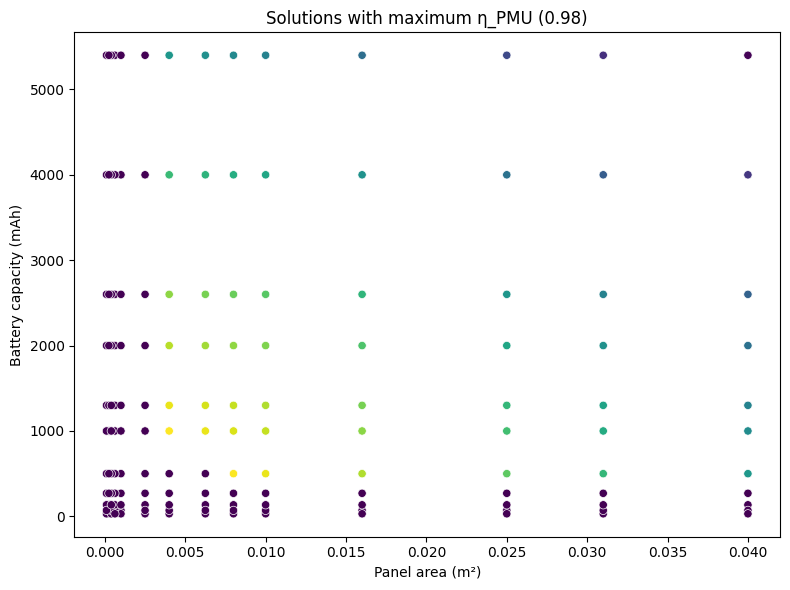

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

eta_max = summary['eta_PMU'].max()
df_plane = summary[summary['eta_PMU'] == eta_max]

plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df_plane,
    x='panel_area_m2',
    y='C_batt_mAh',
    hue='score',
    palette='viridis'
)

ax.get_legend().remove()

plt.title(f"Solutions with maximum η_PMU ({eta_max})")
plt.xlabel("Panel area (m²)")
plt.ylabel("Battery capacity (mAh)")
plt.tight_layout()
plt.show()


## C12. Histogram

In [11]:
# C11 — Histogram of score distribution

fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()


## C13. Best combinations

In [34]:
for _, row in summary[summary["score"] == summary['score'].max()].iterrows():
    print(row)


panel_area_m2             0.004000
C_batt_mAh             1000.000000
eta_PMU                   0.980000
hours_total            8760.000000
hours_soc_min             0.000000
hours_soc_full         2150.000000
soc_mean                  0.899797
soc_std                   0.114043
surplus_mAh          226770.936965
deficit_mAh           64886.200390
autonomy_hours         8760.000000
failure_hours             0.000000
soc_min_fraction          0.000000
soc_full_fraction         0.245434
net_mAh              161884.736575
score                     1.000000
Name: 0, dtype: float64


In [ ]:
import plotly.graph_objects as go

eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_mAh",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (mAh)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()
